# Sesión 2: Taller de Análisis de Datos con NumPy, Pandas y Seaborn

**Objetivos:**
-   Entender la estructura `ndarray` de NumPy y el poder de las **operaciones vectorizadas**.
-   Conocer las estructuras de datos fundamentales de Pandas: `DataFrame` y `Series`.
-   Aprender el flujo de trabajo básico: cargar, inspeccionar, seleccionar, filtrar y transformar datos.
-   Realizar agregaciones de datos con `.groupby()` para responder preguntas.
-   Crear visualizaciones clave con Seaborn para comunicar hallazgos.

## 1. El Fundamento: NumPy y el Poder de los Arrays

Antes de Pandas, existió NumPy. Es la librería fundamental para la computación científica en Python. Su objeto principal es el **`ndarray` (N-dimensional array)**.

* **¿Qué es un `ndarray`?** Es una parrilla de valores, **todos del mismo tipo**. Piensa en ello como una lista de Python con superpoderes.
* **¿Por qué NumPy y no una lista?**
    1.  **Velocidad:** Las operaciones en NumPy son mucho más rápidas porque están implementadas en C.
    2.  **Conveniencia (Vectorización):** Permite aplicar una operación a un array entero de una sola vez, sin necesidad de bucles `for`.



**Ejemplo de Vectorización:**
```python
# Con una lista de Python
precios_lista = [10, 20, 30, 40]
precios_con_iva_lista = []
for precio in precios_lista:
    precios_con_iva_lista.append(precio * 1.21)

# Con un array de NumPy
precios_array = np.array([10, 20, 30, 40])
precios_con_iva_array = precios_array * 1.21 # ¡Así de simple!
```

### 🛠️ Ejercicio de Calentamiento con NumPy

Imagina que recibes datos brutos de sensores como una lista de números. Tu tarea es usar NumPy para limpiarlos y analizarlos rápidamente.

**Datos de Partida:** `[15.5, 17.2, 16.8, -999.0, 18.1, 14.9, 17.2, -999.0, 18.3]`
(El valor `-999.0` representa un error del sensor).

**Tareas:**
1.  Crea un array de NumPy a partir de la lista.
2.  Usando **indexación booleana**, crea un nuevo array llamado `temperaturas_validas` que contenga solo los valores que no sean `-999.0`.
3.  Convierte todas las temperaturas válidas de Celsius a Fahrenheit. La fórmula es: `F = C * 9/5 + 32`. Hazlo en una sola línea de código (vectorización).
4.  Calcula la temperatura **media, máxima y mínima** en Fahrenheit usando los métodos del array.

In [3]:
import numpy as np
# Datos de partida
temperaturas_celsius_lista = [15.5, 17.2, 16.8, -999.0, 18.1, 14.9, 17.2, -999.0, 18.3]

In [4]:
# 1. Crea el array
temperaturas_celsius_lista_np = np.array(temperaturas_celsius_lista)

In [5]:
# 2. Filtra los valores no válidos
temperaturas_validas = temperaturas_celsius_lista_np[temperaturas_celsius_lista_np != -999.0]
# [temperaturas_celsius_lista_np != -999.0] es una mascara que devuelve true o false por cada valor del array original

In [6]:
# 3. Convierte a Fahrenheit
temperaturas_fahrenheit = temperaturas_celsius_lista_np * 9/5 + 32

In [7]:
# 4. Calcula las estadísticas
temp_media_f = temperaturas_fahrenheit.mean()
temp_max_f = temperaturas_fahrenheit.max()
temp_min_f = temperaturas_fahrenheit.min()

In [8]:
# Imprime tus resultados
print(f"Temperaturas en Fahrenheit: {temperaturas_fahrenheit}")
print(f"Temperatura media (F): {temp_media_f:.2f}")
print(f"Temperatura máxima (F): {temp_max_f:.2f}")
print(f"Temperatura mínima (F): {temp_min_f:.2f}")

Temperaturas en Fahrenheit: [   59.9     62.96    62.24 -1766.2     64.58    58.82    62.96 -1766.2
    64.94]
Temperatura media (F): -344.00
Temperatura máxima (F): 64.94
Temperatura mínima (F): -1766.20


---
## 2. Pandas: El "Excel con Superpoderes"

NumPy es fantástico para datos numéricos, pero ¿qué pasa si tenemos una tabla con diferentes tipos de datos (números, texto, fechas) y queremos usar etiquetas en lugar de índices (nombres de columna)? Para eso, necesitamos **Pandas**.

* **`DataFrame`**: Es una tabla de 2 dimensiones, como una hoja de cálculo.
* **`Series`**: Es una sola columna de un DataFrame.

Vamos a empezar cargando el dataset del Titanic y realizando una primera inspección.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")

# 1. Cargar datos desde una URL
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# 2. Inspección básica
print("--- Primeras 5 filas ---")
print(df.head())

print("\n--- Información general y tipos de datos ---")
df.info()

print("\n--- Resumen estadístico de las columnas numéricas ---")
print(df.describe())

--- Primeras 5 filas ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

## 2. Manipulación de Datos: Seleccionar, Filtrar y Transformar

Ahora que tenemos los datos, vamos a "jugar" con ellos.

* **Seleccionar columnas:** `df['NombreDeLaColumna']`
* **Filtrar filas:** `df[df['NombreDeLaColumna'] > valor]` (esto se llama "máscara booleana").
* **Crear nuevas columnas:** `df['NuevaColumna'] = df['ColumnaExistente'] * 2`
* **Manejar datos nulos:** Primero los contamos con `df.isnull().sum()` y luego decidimos si rellenarlos (`.fillna()`) o eliminarlos (`.dropna()`).

In [10]:
# **Manejar datos nulos:** Primero los contamos con `df.isnull().sum()` y luego decidimos si rellenarlos (`.fillna()`) o eliminarlos (`.dropna()`).

## 3. La Herramienta Más Potente: Agregación con `.groupby()`

`.groupby()` nos permite responder preguntas agrupando los datos por una o más categorías. Sigue una lógica de **"Separar-Aplicar-Combinar"**:
1.  **Separar** los datos en grupos (ej. hombres y mujeres).
2.  **Aplicar** una función a cada grupo (ej. calcular la media de edad).
3.  **Combinar** los resultados en una nueva tabla.

Por ejemplo, para saber la edad media de los pasajeros por sexo:
`df.groupby('Sex')['Age'].mean()`

---
## Preguntas de recap – Sesión 1

1. ¿Qué ventaja tienen los **DataFrames de pandas** frente a listas o diccionarios para trabajar con datos?  
2. ¿Qué diferencia hay entre `df.head()` y `df.info()`?  
3. Si tengo un DataFrame con una columna de texto llamada `"nombre"`, ¿cómo selecciono solo esa columna?  
4. ¿Cómo podemos manejar valores nulos en pandas?
---


## 4. Visualización con Seaborn

"Una imagen vale más que mil tablas". Seaborn es una librería que nos permite crear gráficos estadísticos atractivos con muy poco código.

* **Histograma:** Para ver la distribución de una variable numérica.
* **Gráfico de Barras:** Para comparar una variable numérica entre diferentes categorías.
* **Gráfico de Cajas (Boxplot):** Para ver la distribución de una variable numérica entre categorías.
* **Gráfico de Dispersión (Scatterplot):** Para ver la relación entre dos variables numéricas.

---
## 🛠️ EJERCICIO: Mini-Análisis del Titanic

¡Tu turno! Responde a las siguientes preguntas usando las herramientas que acabamos de ver. Cada pregunta debe ser respondida con una o más celdas de código y, si es necesario, una visualización.

**Preguntas de Investigación:**

1.  **Supervivencia General:** ¿Cuántas personas sobrevivieron y cuántas murieron? Muestra los resultados numéricamente.
2.  **Supervivencia por Sexo:** ¿Cuál fue la tasa de supervivencia (el porcentaje) para hombres y para mujeres?
3.  **Limpieza de Datos:** La columna 'Age' tiene valores nulos. Rellena los datos faltantes con la **mediana** de la edad de todos los pasajeros.
4.  **Visualización por Clase:** Crea un **gráfico de barras** que muestre la tasa de supervivencia para cada clase de pasajero (`Pclass`). ¿Qué clase tenía más probabilidades de sobrevivir?
5.  **Visualización por Edad:** Crea un **histograma** de la columna 'Age' (ya sin nulos). ¿Qué rango de edad era el más común en el barco?
6.  **(Bonus) Creación de Característica:** Crea una nueva columna llamada `FamilySize` que sea la suma de `SibSp` (hermanos/cónyuges) y `Parch` (padres/hijos) más uno (el propio pasajero).

In [11]:
# ESPACIO PARA EL EJERCICIO

# Pregunta 1: Supervivencia General
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [12]:
# Pregunta 2: Supervivencia por Sexo
df.groupby('Sex')['Survived'].mean() * 100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [13]:
# Pregunta 3: Limpieza de Datos
mediana_edad = df['Age'].median()

df['Age'].fillna(mediana_edad)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

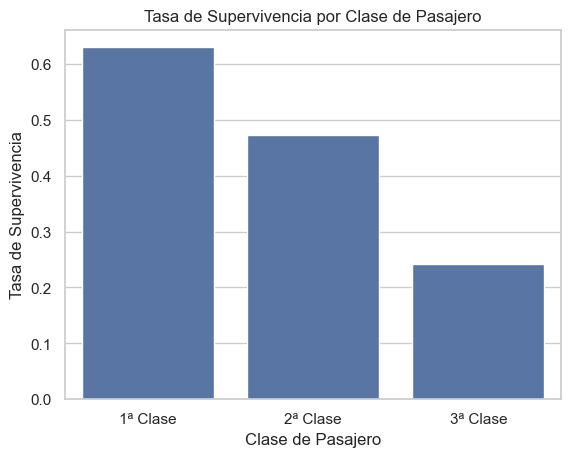

In [14]:
# Pregunta 4: Visualización por Clase
supervivencia_por_clase = df.groupby('Pclass')['Survived'].mean()

sns.barplot(x=supervivencia_por_clase.index, y=supervivencia_por_clase.values)
plt.title('Tasa de Supervivencia por Clase de Pasajero')
plt.xlabel('Clase de Pasajero')
plt.ylabel('Tasa de Supervivencia')
plt.xticks(ticks=[0, 1, 2], labels=['1ª Clase', '2ª Clase', '3ª Clase'])
plt.show()

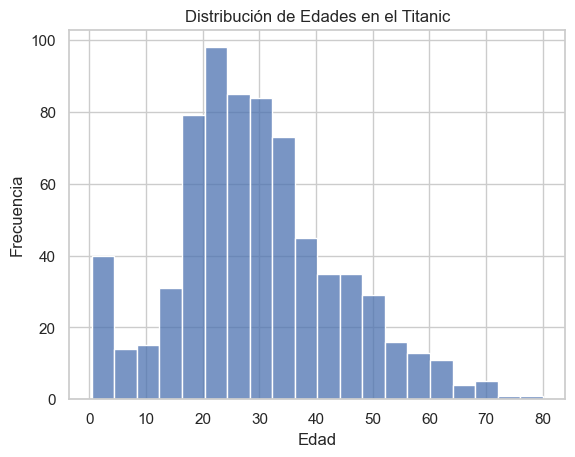

In [15]:
# Pregunta 5: Visualización por Edad
sns.histplot(df['Age'])
plt.title('Distribución de Edades en el Titanic')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

In [16]:
# Pregunta 6: (Bonus) Creación de Característica
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

---
## Preguntas de recap – Sesión 2

1. ¿Qué comando usamos para crear gráficos rápidos a partir de un DataFrame?  
2. ¿Qué diferencia hay entre `df.groupby()` y `df.value_counts()`?  
3. Si queremos ordenar un DataFrame por la columna `"ventas"` de mayor a menor, ¿qué comando usamos?  
4. ¿Por qué es importante visualizar los datos además de analizarlos con estadísticas?
---


## Bonus Task Opcional – Sesión 2

Usando el mismo dataset (`titanic`):

1. Calcula la edad promedio de los pasajeros por clase (pclass).
2. Haz un gráfico de barras que muestre el número de pasajeros por clase (`pclass`).  
3. Haz un gráfico de barras que compare la tasa de supervivencia (`survived`) entre hombres y mujeres.  
4. (Avanzado): Haz un gráfico combinado que muestre la edad promedio de los pasajeros por clase y por sexo.

In [17]:
#Pregunta 1
df.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

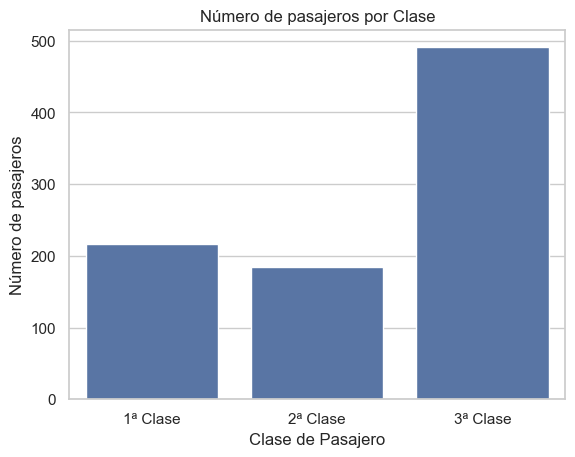

In [18]:
#Pregunta 2
supervivencia_por_clase = df.value_counts('Pclass')

sns.barplot(x=supervivencia_por_clase.index, y=supervivencia_por_clase.values)
plt.title('Número de pasajeros por Clase')
plt.xlabel('Clase de Pasajero')
plt.ylabel('Número de pasajeros')
plt.xticks(ticks=[0, 1, 2], labels=['1ª Clase', '2ª Clase', '3ª Clase'])
plt.show()

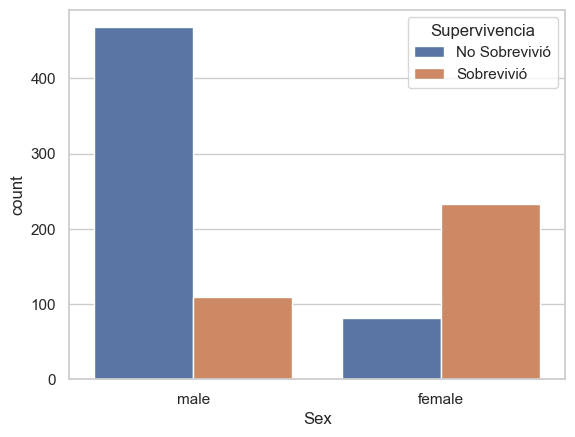

In [19]:
#Pregunta 3
sns.countplot(x='Sex', hue='Survived', data=df)
#hue divide automáticamente en sobrevivió y no sobrevivió
plt.legend(title='Supervivencia', labels=['No Sobrevivió', 'Sobrevivió'])

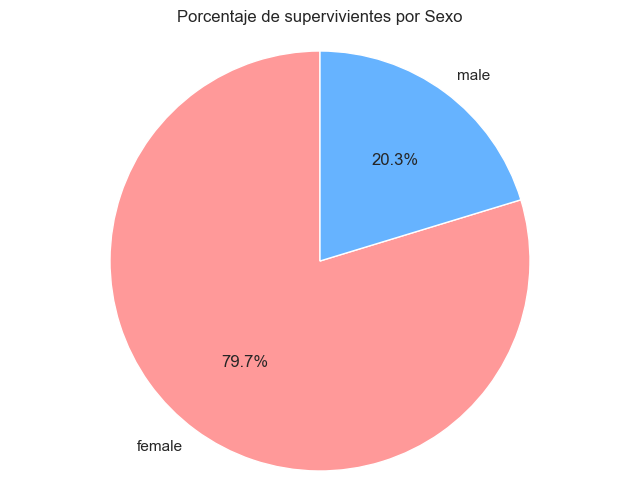

In [32]:
supervivencia_por_sexo = df.groupby('Sex')['Survived'].mean() * 100

plt.figure(figsize=(8, 6))
plt.pie(supervivencia_por_sexo.values, 
        labels=supervivencia_por_sexo.index, 
        autopct='%0.1f%%', 
        startangle=90, 
        colors=['#ff9999','#66b3ff'])
plt.title('Porcentaje de supervivientes por Sexo')
plt.axis('equal')
#para centrarlo
plt.show()

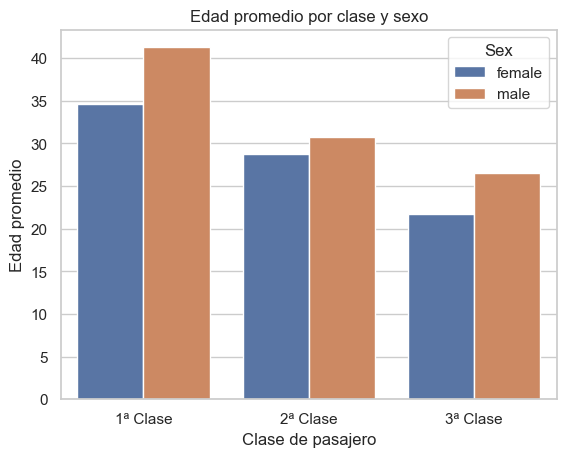

In [33]:
#Pregunta 4

# Agrupar por clase y sexo, y calcular la edad promedio
edad_promedio = df.groupby(['Pclass', 'Sex'])['Age'].mean().reset_index()

# Crear gráfico combinado
sns.barplot(data=edad_promedio, x='Pclass', y='Age', hue='Sex')
plt.title('Edad promedio por clase y sexo')
plt.xlabel('Clase de pasajero')
plt.ylabel('Edad promedio')
plt.xticks(ticks=[0, 1, 2], labels=['1ª Clase', '2ª Clase', '3ª Clase'])
plt.show()
